# Optical-Only KN Inference on ASTRO Data

Use an optical-only checkpoint to run inference on ASTRO simulation products generated by `LSST+WFST` scripts.
This notebook reads SNANA `*_HEAD.FITS` + `*_PHOT.FITS` from `*_KN_ASTRO_COMBINED` and outputs KN candidate scores.


In [41]:
# Imports and path setup
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from astropy.io import fits
import matplotlib.pyplot as plt

OPTICAL_ONLY_DIR = Path('/fred/oz016/bgao_kn/ML+GW+KN/Model/optical_only')
MODEL_DIR = OPTICAL_ONLY_DIR.parent
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from model import OpticalKNClassifier

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


Torch: 2.9.1+cu126
CUDA available: False


## Configuration

Set survey/checkpoint/data paths here. By default this notebook uses `*_KN_ASTRO_COMBINED` products under `SNANA/SNDATA_ROOT/SIM`.


In [42]:
# User configuration
DATA_SOURCE = '170817A'  # 'ASTRO' or '170817A'
SURVEY = 'WFST'        # 'LSST' or 'WFST'

# Preferred: point to your trained best checkpoint.
CHECKPOINT_PATH = Path(
    '/fred/oz016/bgao_kn/data/model/checkpoints_optical/optical_only/optical_only_kn_v0/optical_only_best.pth'
)

# Optional fallback: auto-resolve from latest_run.txt when CHECKPOINT_PATH does not exist.
CKPT_ROOT = Path('/fred/oz016/bgao_kn/data/model/checkpoints_optical/optical_only')

SIM_ROOT = Path('/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM')

survey = SURVEY.upper()
source = DATA_SOURCE.upper()

if survey not in {'LSST', 'WFST'}:
    raise ValueError(f'Unsupported SURVEY={SURVEY}')

if source == 'ASTRO':
    data_tag = f'{survey}_KN_ASTRO_COMBINED'
elif source == '170817A':
    data_tag = f'{survey}_KN_170817A'
else:
    raise ValueError(f"Unsupported DATA_SOURCE={DATA_SOURCE}. Use 'ASTRO' or '170817A'.")

COMBINED_DIR = SIM_ROOT / data_tag
HEAD_PATH = COMBINED_DIR / f'{data_tag}_HEAD.FITS'
PHOT_PATH = COMBINED_DIR / f'{data_tag}_PHOT.FITS'

OUTPUT_DIR = OPTICAL_ONLY_DIR / 'notebook_outputs' / f"{survey.lower()}_{source.lower()}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 1024
NUM_WORKERS = 0
MAX_SAMPLES = None  # e.g. 50000; None means all
THRESHOLD = None    # None => use checkpoint val_metrics['op_threshold'] if available, else 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if not CHECKPOINT_PATH.exists():
    latest_run = CKPT_ROOT / 'latest_run.txt'
    if latest_run.exists():
        run_name = latest_run.read_text(encoding='utf-8').strip()
        candidate = CKPT_ROOT / run_name / 'optical_only_best.pth'
        if candidate.exists():
            CHECKPOINT_PATH = candidate

print('DATA_SOURCE:', DATA_SOURCE)
print('SURVEY:', SURVEY)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('HEAD_PATH:', HEAD_PATH)
print('PHOT_PATH:', PHOT_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('DEVICE:', DEVICE)


DATA_SOURCE: 170817A
SURVEY: WFST
CHECKPOINT_PATH: /fred/oz016/bgao_kn/data/model/checkpoints_optical/optical_only/optical_only_kn_v0/optical_only_best.pth
HEAD_PATH: /fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/WFST_KN_170817A/WFST_KN_170817A_HEAD.FITS
PHOT_PATH: /fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/WFST_KN_170817A/WFST_KN_170817A_PHOT.FITS
OUTPUT_DIR: /fred/oz016/bgao_kn/ML+GW+KN/Model/optical_only/notebook_outputs/wfst_170817a
DEVICE: cpu


## Helper Functions


In [43]:
BAND_TO_INDEX = {
    # Canonical LSST keys
    'LSST-u': 0, 'LSST-g': 1, 'LSST-r': 2, 'LSST-i': 3, 'LSST-z': 4, 'LSST-Y': 5,
    # WFST keys (map to closest matching channels used by optical encoder)
    'WFST-u': 0, 'WFST-g': 1, 'WFST-r': 2, 'WFST-i': 3, 'WFST-z': 4, 'WFST-Y': 5,
    # Bare keys
    'u': 0, 'g': 1, 'r': 2, 'i': 3, 'z': 4, 'Y': 5, 'y': 5,
}


def _decode(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode(errors='ignore').strip()
    return str(x).strip()


def build_ref_time(batch_size, n_ref, ref_start, ref_end, device, dtype):
    ref = torch.linspace(ref_start, ref_end, n_ref, dtype=dtype, device=device)
    return ref.unsqueeze(0).repeat(batch_size, 1)


class AstroOpticalDataset(Dataset):
    def __init__(self, times, values, masks, errors, coords, meta_df):
        self.times = torch.from_numpy(times.astype(np.float32))
        self.values = torch.from_numpy(values.astype(np.float32))
        self.masks = torch.from_numpy(masks.astype(np.float32))
        self.errors = torch.from_numpy(errors.astype(np.float32))
        self.coords = torch.from_numpy(coords.astype(np.float32))
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return self.times.shape[0]

    def __getitem__(self, idx):
        # Placeholder label for interface compatibility; not used in inference.
        label = torch.tensor(0.0, dtype=torch.float32)
        return (
            self.times[idx],
            self.values[idx],
            self.masks[idx],
            self.errors[idx],
            self.coords[idx],
            label,
        )


def extract_astro_optical_arrays(head_path, phot_path, max_len=200, min_nobs=5, time_scale=100.0):
    if not head_path.exists():
        raise FileNotFoundError(head_path)
    if not phot_path.exists():
        raise FileNotFoundError(phot_path)

    with fits.open(head_path, memmap=False) as hdul_h, fits.open(phot_path, memmap=False) as hdul_p:
        head = hdul_h[1].data
        phot = hdul_p[1].data

    mjd_all = np.asarray(phot['MJD'])
    flux_all = np.asarray(phot['FLUXCAL'])
    fluxerr_all = np.asarray(phot['FLUXCALERR'])
    band_all = np.asarray(phot['BAND'])

    cols = set(head.columns.names)
    if 'PTROBS_MIN' not in cols or 'PTROBS_MAX' not in cols:
        raise KeyError('HEAD FITS missing PTROBS_MIN/PTROBS_MAX')

    unknown_bands = {}
    vals_list, errs_list, masks_list, times_list, coords_list = [], [], [], [], []
    raw_vals_list, raw_errs_list, raw_times_list = [], [], []
    meta_rows = []

    for i in range(len(head)):
        start = int(head['PTROBS_MIN'][i]) - 1
        end = int(head['PTROBS_MAX'][i])
        if end <= start:
            continue

        lc_mjd = mjd_all[start:end]
        lc_flux_raw = flux_all[start:end]
        lc_err_raw = fluxerr_all[start:end]
        lc_band = band_all[start:end]

        if len(lc_mjd) < min_nobs:
            continue

        # NDET: number of detections with SNR > 5 using raw (non-normalized) flux/error.
        valid_det = np.isfinite(lc_flux_raw) & np.isfinite(lc_err_raw) & (lc_err_raw > 0)
        if np.any(valid_det):
            snr = lc_flux_raw[valid_det] / lc_err_raw[valid_det]
            ndet = int(np.sum(snr > 5.0))
        else:
            ndet = 0

        peak_mjd = float(head['PEAKMJD'][i]) if 'PEAKMJD' in cols else float(np.median(lc_mjd))
        rel_t = (lc_mjd - peak_mjd) / time_scale

        # Keep at most max_len points; preserve identical indices for raw and normalized arrays.
        if len(rel_t) > max_len:
            keep = np.argsort(np.abs(rel_t))[:max_len]
            keep = np.sort(keep)
            lc_mjd = lc_mjd[keep]
            rel_t = rel_t[keep]
            lc_flux_raw = lc_flux_raw[keep]
            lc_err_raw = lc_err_raw[keep]
            lc_band = lc_band[keep]

        # Model inputs (normalized flux)
        lc_flux = lc_flux_raw.copy()
        lc_err = lc_err_raw.copy()
        std = float(np.std(lc_flux))
        mean = float(np.mean(lc_flux))
        if not np.isfinite(std) or std < 1e-8:
            std = 1.0
        lc_flux = (lc_flux - mean) / (std + 1e-8)
        lc_err = lc_err / (std + 1e-8)

        val_mat = np.zeros((max_len, 6), dtype=np.float32)
        err_mat = np.zeros((max_len, 6), dtype=np.float32)
        mask_mat = np.zeros((max_len, 6), dtype=np.float32)
        time_vec = np.zeros((max_len,), dtype=np.float32)

        # Raw arrays for plotting
        raw_val_mat = np.zeros((max_len, 6), dtype=np.float32)
        raw_err_mat = np.zeros((max_len, 6), dtype=np.float32)
        raw_time_vec = np.zeros((max_len,), dtype=np.float32)

        for t in range(len(rel_t)):
            band = _decode(lc_band[t])
            band_idx = BAND_TO_INDEX.get(band)
            if band_idx is None:
                if band not in {'', '-'}:
                    unknown_bands[band] = unknown_bands.get(band, 0) + 1
                continue

            val_mat[t, band_idx] = float(lc_flux[t])
            err_mat[t, band_idx] = float(lc_err[t])
            mask_mat[t, band_idx] = 1.0
            time_vec[t] = float(rel_t[t])

            raw_val_mat[t, band_idx] = float(lc_flux_raw[t])
            raw_err_mat[t, band_idx] = float(lc_err_raw[t])
            raw_time_vec[t] = float(lc_mjd[t])

        ra = float(head['RA'][i]) if 'RA' in cols else 0.0
        dec = float(head['DEC'][i]) if 'DEC' in cols else 0.0
        snid = _decode(head['SNID'][i]) if 'SNID' in cols else str(i)
        nobs = int(head['NOBS'][i]) if 'NOBS' in cols else int(len(rel_t))

        vals_list.append(val_mat)
        errs_list.append(err_mat)
        masks_list.append(mask_mat)
        times_list.append(time_vec)
        coords_list.append(np.array([ra, dec], dtype=np.float32))

        raw_vals_list.append(raw_val_mat)
        raw_errs_list.append(raw_err_mat)
        raw_times_list.append(raw_time_vec)

        meta_rows.append({
            'SNID': snid,
            'NOBS': nobs,
            'NDET': ndet,
            'PEAKMJD': peak_mjd,
            'RA': ra,
            'DEC': dec,
            'row_index': i,
        })

    if len(vals_list) == 0:
        raise RuntimeError('No valid light curves extracted from ASTRO combined FITS.')

    meta_df = pd.DataFrame(meta_rows)
    arrays = {
        'values': np.stack(vals_list, axis=0),
        'errors': np.stack(errs_list, axis=0),
        'masks': np.stack(masks_list, axis=0),
        'times': np.stack(times_list, axis=0),
        'coords': np.stack(coords_list, axis=0),
        'raw_values': np.stack(raw_vals_list, axis=0),
        'raw_errors': np.stack(raw_errs_list, axis=0),
        'raw_times': np.stack(raw_times_list, axis=0),
        'meta': meta_df,
        'unknown_bands': unknown_bands,
    }
    return arrays


def load_optical_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    ckpt_args = ckpt.get('args', {}) if isinstance(ckpt.get('args', {}), dict) else {}

    def _arg(name, default):
        return ckpt_args[name] if name in ckpt_args and ckpt_args[name] is not None else default

    model = OpticalKNClassifier(
        optical_input_dim=6,
        ref_time_dim=_arg('ref_dim', 64),
        enc_dim=_arg('enc_dim', 64),
        opt_dropout=_arg('opt_dropout', 0.1),
        feature_dropout=_arg('feature_dropout', 0.0),
        head_hidden_dim=_arg('head_hidden_dim', None),
        head_dropout=_arg('head_dropout', 0.2),
        include_coords=bool(_arg('include_coords', False)),
    )

    state_dict = ckpt.get('model_state_dict', ckpt)
    if not isinstance(state_dict, dict):
        raise ValueError('Invalid checkpoint: no state_dict found.')
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    model.to(device)
    model.eval()

    ref_cfg = {
        'n_ref': int(_arg('n_ref', 64)),
        'ref_start': float(_arg('ref_start', -0.3)),
        'ref_end': float(_arg('ref_end', 0.6)),
    }

    ckpt_threshold = None
    if isinstance(ckpt.get('val_metrics', None), dict):
        ckpt_threshold = ckpt['val_metrics'].get('op_threshold', None)

    print(f'Loaded checkpoint: {checkpoint_path}')
    print(f'Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}')
    print('Reference config:', ref_cfg)
    print('Checkpoint threshold(op_threshold):', ckpt_threshold)
    return model, ckpt_args, ref_cfg, ckpt_threshold


@torch.no_grad()
def predict_probabilities(model, dataset, device, n_ref, ref_start, ref_end, batch_size=1024, num_workers=0):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    if device.type == 'cuda':
        amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    else:
        amp_dtype = torch.float32

    all_probs = []
    ref_cache = None

    for batch in tqdm(loader, desc='Infer'):
        opt_t, opt_v, opt_mask, opt_err, opt_coords, _labels = batch
        opt_t = opt_t.to(device, non_blocking=True)
        opt_v = opt_v.to(device, non_blocking=True)
        opt_mask = opt_mask.to(device, non_blocking=True)
        opt_err = opt_err.to(device, non_blocking=True)
        opt_coords = opt_coords.to(device, non_blocking=True)

        bsz = opt_t.shape[0]
        if ref_cache is None or ref_cache.shape[0] != bsz or ref_cache.dtype != opt_t.dtype:
            ref_cache = build_ref_time(bsz, n_ref, ref_start, ref_end, device, opt_t.dtype)

        with autocast(device_type='cuda', dtype=amp_dtype, enabled=(device.type == 'cuda')):
            logits = model(opt_coords, opt_t, opt_v, ref_cache, opt_mask, opt_err).squeeze(-1)
            probs = torch.sigmoid(logits.float())

        all_probs.append(probs.cpu().numpy())

    return np.concatenate(all_probs, axis=0)


## Run Inference


In [44]:
arrays = extract_astro_optical_arrays(HEAD_PATH, PHOT_PATH, max_len=200)
meta_df = arrays['meta'].copy()

if MAX_SAMPLES is not None and MAX_SAMPLES < len(meta_df):
    keep = np.arange(int(MAX_SAMPLES), dtype=np.int64)
    meta_df = meta_df.iloc[keep].reset_index(drop=True)
    for k in ['values', 'errors', 'masks', 'times', 'coords', 'raw_values', 'raw_errors', 'raw_times']:
        arrays[k] = arrays[k][keep]

print('Samples:', len(meta_df))
print('Unknown bands (ignored):', arrays['unknown_bands'])

dataset = AstroOpticalDataset(
    times=arrays['times'],
    values=arrays['values'],
    masks=arrays['masks'],
    errors=arrays['errors'],
    coords=arrays['coords'],
    meta_df=meta_df,
)

model, ckpt_args, ref_cfg, ckpt_threshold = load_optical_model(CHECKPOINT_PATH, DEVICE)

use_threshold = THRESHOLD
if use_threshold is None:
    use_threshold = ckpt_threshold if ckpt_threshold is not None else 0.5
use_threshold = float(use_threshold)

probs = predict_probabilities(
    model=model,
    dataset=dataset,
    device=DEVICE,
    n_ref=ref_cfg['n_ref'],
    ref_start=ref_cfg['ref_start'],
    ref_end=ref_cfg['ref_end'],
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

meta_df['dataset_index'] = np.arange(len(meta_df), dtype=np.int64)
meta_df['prob_kn'] = probs
meta_df['pred_label'] = (meta_df['prob_kn'] >= use_threshold).astype(int)
meta_df = meta_df.sort_values('prob_kn', ascending=False).reset_index(drop=True)

out_csv = OUTPUT_DIR / f"{SURVEY.lower()}_{DATA_SOURCE.lower()}_optical_only_predictions.csv"
meta_df.to_csv(out_csv, index=False)

print('Threshold:', use_threshold)
print('Candidates above threshold:', int(meta_df['pred_label'].sum()), '/', len(meta_df))
print('Saved:', out_csv)
meta_df


Samples: 69
Unknown bands (ignored): {}
Loaded checkpoint: /fred/oz016/bgao_kn/data/model/checkpoints_optical/optical_only/optical_only_kn_v0/optical_only_best.pth
Missing keys: 0 | Unexpected keys: 0
Reference config: {'n_ref': 64, 'ref_start': -0.3, 'ref_end': 0.6}
Checkpoint threshold(op_threshold): 0.4130000174045563


Infer:   0%|          | 0/1 [00:00<?, ?it/s]

Infer: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]

Threshold: 0.4130000174045563
Candidates above threshold: 46 / 69
Saved: /fred/oz016/bgao_kn/ML+GW+KN/Model/optical_only/notebook_outputs/wfst_170817a/wfst_170817a_optical_only_predictions.csv


,SNID,NOBS,NDET,PEAKMJD,RA,DEC,row_index,dataset_index,prob_kn,pred_label
0,320,234,1,61537.613281,209.707031,5.679190,54,54,0.987469,1
1,111,225,1,61549.683594,227.988281,-1.492246,19,19,0.982805,1
2,370,274,4,61343.636719,23.027344,-1.492246,62,62,0.977695,1
3,93,279,4,61474.738281,165.234375,1.641510,14,14,0.968782,1
4,239,261,4,61351.601562,356.835937,1.044512,38,38,0.964442,1
...,...,...,...,...,...,...,...,...,...,...
64,319,306,1,61448.933594,212.343750,-0.149208,53,53,0.052301,0
65,329,264,2,61277.835938,36.914062,3.134927,56,56,0.048736,0
66,383,276,2,61335.570312,356.835937,5.829153,66,66,0.029541,0
67,374,273,1,61524.699219,197.578125,-1.044512,63,63,0.003108,0


## Plots and Quick Summary


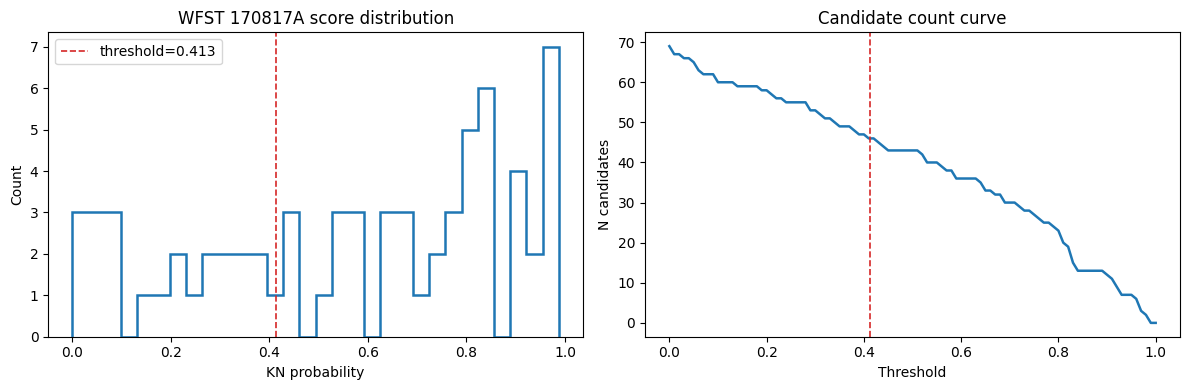

{'survey': 'WFST',
 'data_source': '170817A',
 'n_samples': 69,
 'threshold': 0.4130000174045563,
 'n_candidates': 46,
 'prob_mean': 0.571051299571991,
 'prob_median': 0.6497137546539307,
 'prob_p95': 0.9670464396476746,
 'checkpoint': '/fred/oz016/bgao_kn/data/model/checkpoints_optical/optical_only/optical_only_kn_v0/optical_only_best.pth',
 'head_path': '/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/WFST_KN_170817A/WFST_KN_170817A_HEAD.FITS',
 'phot_path': '/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/WFST_KN_170817A/WFST_KN_170817A_PHOT.FITS'}

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Probability histogram (no fill)
axes[0].hist(meta_df['prob_kn'].values, bins=30, histtype='step', linewidth=1.8)
axes[0].axvline(use_threshold, color='tab:red', linestyle='--', linewidth=1.2, label=f'threshold={use_threshold:.3f}')
axes[0].set_xlabel('KN probability')
axes[0].set_ylabel('Count')
axes[0].set_title(f'{SURVEY} {DATA_SOURCE} score distribution')
axes[0].legend()

# Candidate count vs threshold
thr_grid = np.linspace(0, 1, 101)
cand_counts = [(meta_df['prob_kn'].values >= t).sum() for t in thr_grid]
axes[1].plot(thr_grid, cand_counts, linewidth=1.8)
axes[1].axvline(use_threshold, color='tab:red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('N candidates')
axes[1].set_title('Candidate count curve')

plt.tight_layout()
plt.show()

summary = {
    'survey': SURVEY,
    'data_source': DATA_SOURCE,
    'n_samples': int(len(meta_df)),
    'threshold': float(use_threshold),
    'n_candidates': int((meta_df['prob_kn'].values >= use_threshold).sum()),
    'prob_mean': float(meta_df['prob_kn'].mean()),
    'prob_median': float(meta_df['prob_kn'].median()),
    'prob_p95': float(np.percentile(meta_df['prob_kn'].values, 95.0)),
    'checkpoint': str(CHECKPOINT_PATH),
    'head_path': str(HEAD_PATH),
    'phot_path': str(PHOT_PATH),
}
summary


## Negative Prediction Light Curves

For each predicted negative source (`pred_label == 0`):
- plot raw light curve (`FLUXCAL`, not normalized),
- remove points with `SNR < 3`,
- explicitly mark points with `SNR > 5`.


Predicted negatives: 23 / 69


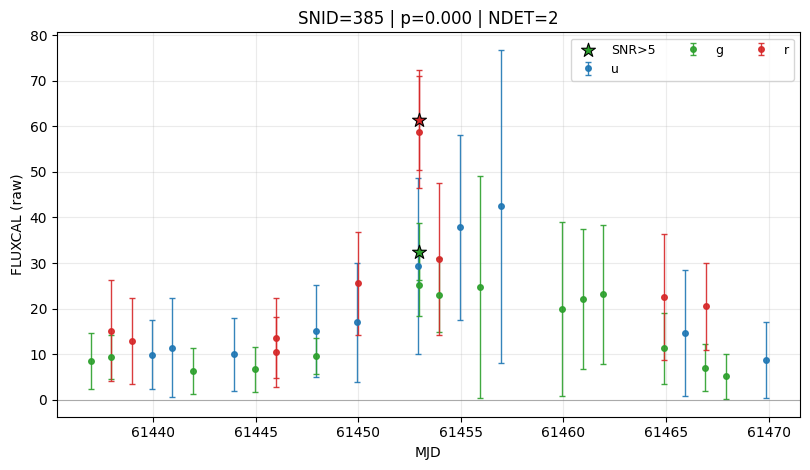

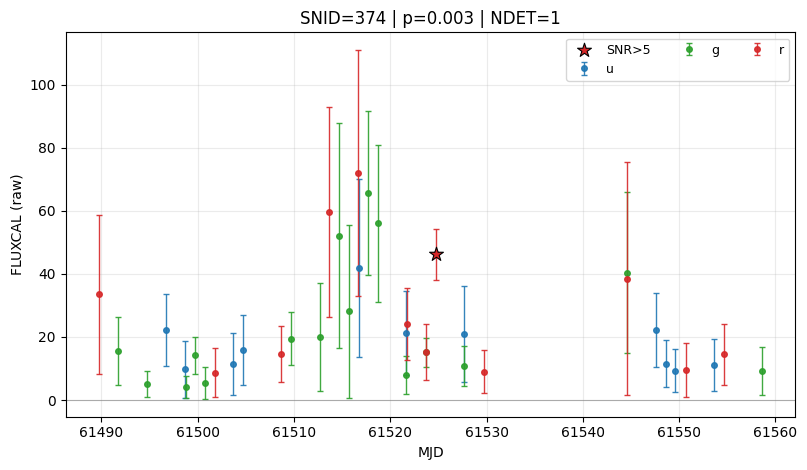

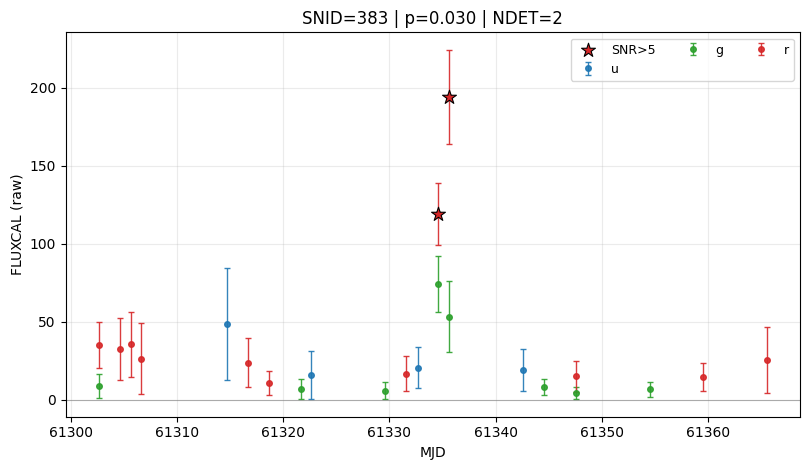

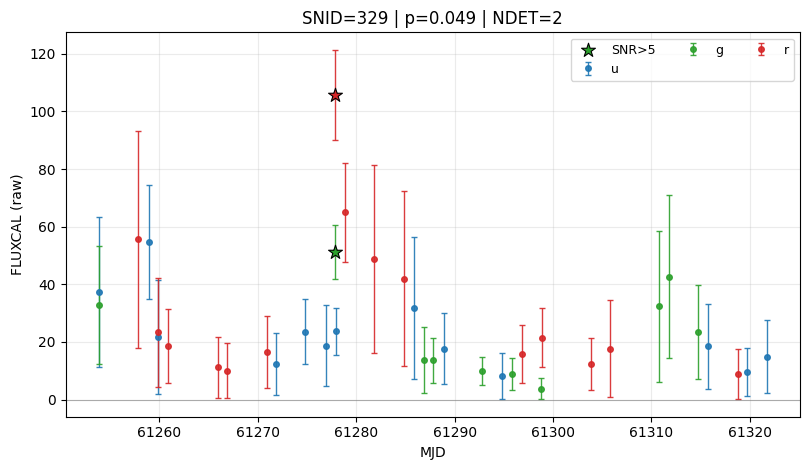

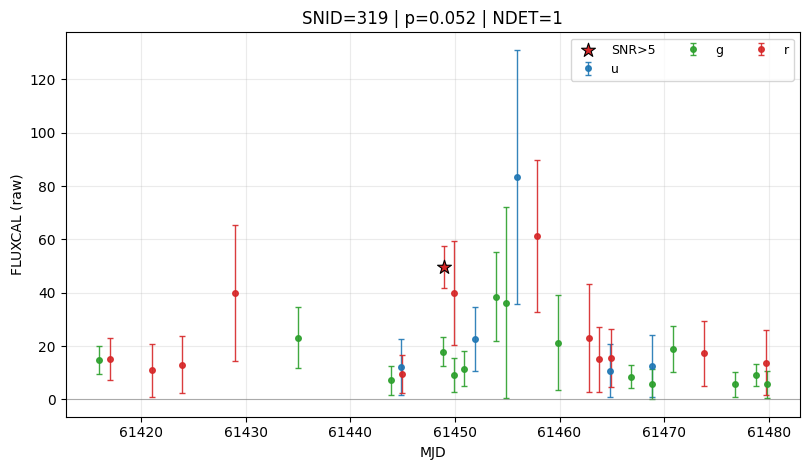

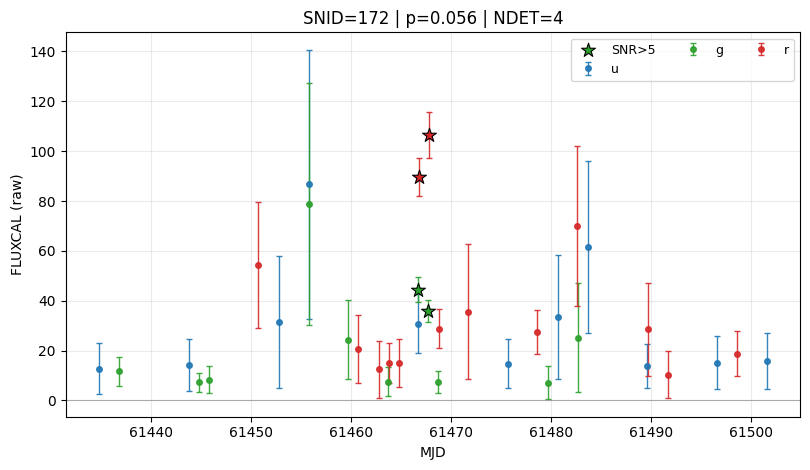

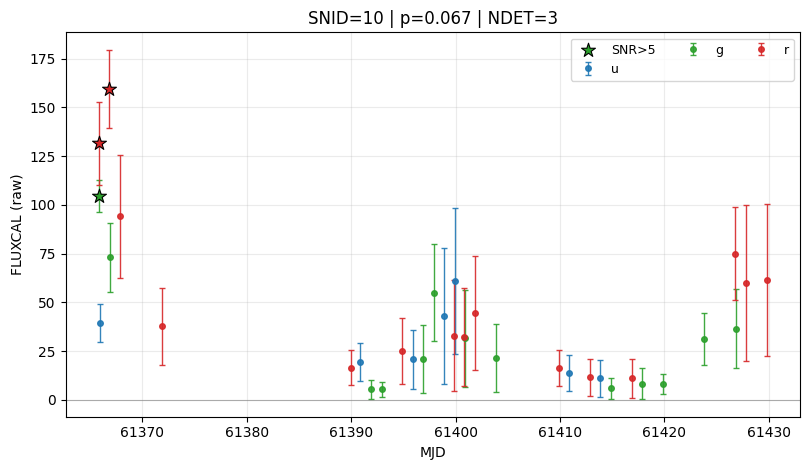

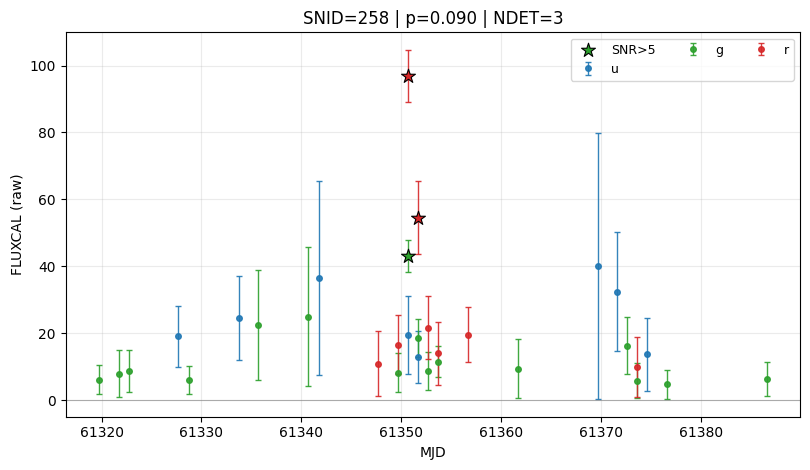

,SNID,NOBS,NDET,PEAKMJD,RA,DEC,row_index,dataset_index,prob_kn,pred_label
0,385,606,2,61452.960938,227.109375,4.331149,68,68,0.000188,0
1,374,273,1,61524.699219,197.578125,-1.044512,63,63,0.003108,0
2,383,276,2,61335.570312,356.835937,5.829153,66,66,0.029541,0
3,329,264,2,61277.835938,36.914062,3.134927,56,56,0.048736,0
4,319,306,1,61448.933594,212.343750,-0.149208,53,53,0.052301,0
5,172,294,4,61467.746094,158.730469,-1.193748,28,28,0.056287,0
6,10,180,3,61366.875000,159.609375,1.044512,1,1,0.067232,0
7,258,285,3,61350.695312,30.058594,0.596842,42,42,0.090243,0


In [46]:
N_NEG_PLOT = 8
NEG_SELECT = 'lowest_prob'  # 'lowest_prob' or 'random'
SNR_MIN = 1.0
SNR_MARK = 5.0

BAND_NAMES = ['u', 'g', 'r', 'i', 'z', 'Y']
BAND_COLORS = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange', 'tab:purple', 'tab:brown']

neg_df = meta_df[meta_df['pred_label'] == 0].copy()
print('Predicted negatives:', len(neg_df), '/', len(meta_df))

if len(neg_df) == 0:
    print('No negative predictions under current threshold.')
    plot_df = neg_df
else:
    if NEG_SELECT == 'random':
        plot_df = neg_df.sample(n=min(N_NEG_PLOT, len(neg_df)), random_state=42)
    else:
        plot_df = neg_df.nsmallest(min(N_NEG_PLOT, len(neg_df)), 'prob_kn')

    plot_df = plot_df.reset_index(drop=True)

    for i in range(len(plot_df)):
        row = plot_df.iloc[i]
        didx = int(row['dataset_index'])

        t_raw = arrays['raw_times'][didx]
        v_raw = arrays['raw_values'][didx]
        e_raw = arrays['raw_errors'][didx]
        m = arrays['masks'][didx]

        fig, ax = plt.subplots(figsize=(8.2, 4.8))
        has_snr_mark = False

        for b in range(6):
            valid = (m[:, b] > 0) & np.isfinite(v_raw[:, b]) & np.isfinite(e_raw[:, b]) & (e_raw[:, b] > 0)
            if not np.any(valid):
                continue

            tb = t_raw[valid]
            vb = v_raw[valid, b]
            eb = e_raw[valid, b]
            snr = vb / eb

            keep = snr >= SNR_MIN
            if not np.any(keep):
                continue

            tb = tb[keep]
            vb = vb[keep]
            eb = eb[keep]
            snr = snr[keep]

            ax.errorbar(
                tb,
                vb,
                yerr=eb,
                fmt='o',
                ms=4,
                lw=1.0,
                capsize=2,
                color=BAND_COLORS[b],
                alpha=0.9,
                label=BAND_NAMES[b],
            )

            high = snr > SNR_MARK
            if np.any(high):
                ax.scatter(
                    tb[high],
                    vb[high],
                    marker='*',
                    s=110,
                    color=BAND_COLORS[b],
                    edgecolors='black',
                    linewidths=0.8,
                    zorder=5,
                    label='SNR>5' if not has_snr_mark else None,
                )
                has_snr_mark = True

        title = f"SNID={row['SNID']} | p={row['prob_kn']:.3f}"
        if 'NDET' in row.index:
            title += f" | NDET={int(row['NDET'])}"

        ax.set_title(title)
        ax.set_xlabel('MJD')
        ax.set_ylabel('FLUXCAL (raw)')
        ax.axhline(0.0, color='gray', lw=0.8, alpha=0.6)
        ax.grid(alpha=0.25)
        ax.legend(ncol=3, fontsize=9)

        plt.tight_layout()
        plt.show()

plot_df


## Parameter Distributions (Including Redshift)

Read extra physical/metadata columns from `HEAD.FITS` and plot distributions such as redshift.


Using redshift column: REDSHIFT_FINAL


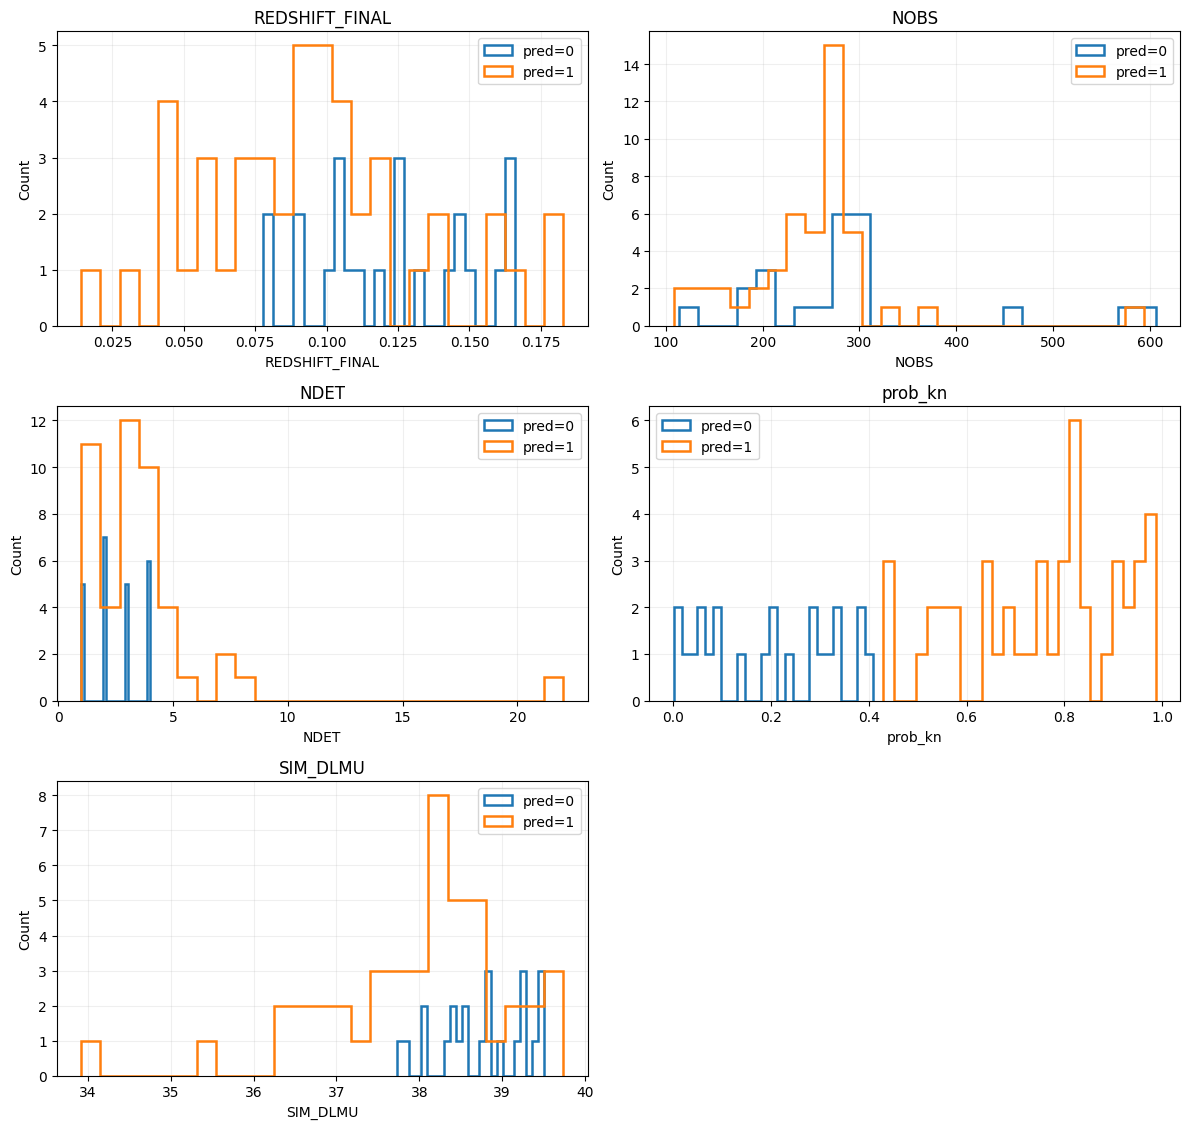

REDSHIFT_FINAL                      NOBS                     NDET  \
                    count      mean    median count        mean median count   
pred_label                                                                     
0                      23  0.123445  0.124220    23  292.347826  276.0    23   
1                      46  0.094745  0.094333    46  251.586957  264.0    46   

                            prob_kn                     SIM_DLMU             \
                mean median   count      mean    median    count       mean   
pred_label                                                                    
0           2.521739    2.0      23  0.194731  0.208523       23  38.747692   
1           3.586957    3.0      46  0.759212  0.798731       46  37.969059   

                       
               median  
pred_label             
0           38.815876  
1           38.175827

,SNID,NOBS,NDET,PEAKMJD,RA,DEC,row_index,dataset_index,prob_kn,pred_label,SIM_REDSHIFT_CMB,SIM_REDSHIFT_HELIO,SIM_REDSHIFT_HOST,REDSHIFT_FINAL,REDSHIFT_HELIO,SIM_DLMU,SIM_LENSDMU,SIM_MUSHIFT,SIM_PEAKMAG_g,SIM_PEAKMAG_r
0,320,234,1,61537.613281,209.707031,5.679190,54,54,0.987469,1,0.134263,0.133248,0.133248,0.134263,0.133248,38.998497,0.0,0.0,99.0,99.0
1,111,225,1,61549.683594,227.988281,-1.492246,19,19,0.982805,1,0.117364,0.116677,0.116677,0.117364,0.116677,38.683681,0.0,0.0,99.0,99.0
2,370,274,4,61343.636719,23.027344,-1.492246,62,62,0.977695,1,0.092361,0.093451,0.093451,0.092361,0.093451,38.131374,0.0,0.0,99.0,99.0
3,93,279,4,61474.738281,165.234375,1.641510,14,14,0.968782,1,0.088850,0.087523,0.087523,0.088850,0.087523,38.037315,0.0,0.0,99.0,99.0
4,239,261,4,61351.601562,356.835937,1.044512,38,38,0.964442,1,0.081246,0.082557,0.082557,0.081246,0.082557,37.837208,0.0,0.0,99.0,99.0


In [47]:
# Merge selected HEAD parameters into meta_df via row_index
with fits.open(HEAD_PATH, memmap=False) as hdul:
    head_data = hdul[1].data
    head_cols = set(head_data.columns.names)

param_df = meta_df.copy()
row_idx = param_df['row_index'].to_numpy(dtype=np.int64)

candidate_cols = [
    'SIM_REDSHIFT_CMB', 'SIM_REDSHIFT_HELIO', 'SIM_REDSHIFT_HOST',
    'REDSHIFT_FINAL', 'REDSHIFT_HELIO',
    'SIM_DLMU', 'SIM_LENSDMU', 'SIM_MUSHIFT',
    'SIM_PEAKMAG_g', 'SIM_PEAKMAG_r', 'SIM_PEAKMAG_i', 'SIM_PEAKMAG_z',
    'NOBS',
]

for col in candidate_cols:
    if col in head_cols:
        vals = np.asarray(head_data[col])[row_idx]
        if vals.dtype.kind in {'S', 'U', 'O'}:
            vals = np.array([str(v).strip() for v in vals], dtype=object)
        else:
            vals = vals.astype(vals.dtype.newbyteorder('='))
        param_df[col] = vals

# Pick a redshift-like column if available
z_priority = ['REDSHIFT_FINAL', 'REDSHIFT_HELIO','SIM_REDSHIFT_CMB', 'SIM_REDSHIFT_HELIO', 'SIM_REDSHIFT_HOST']
z_col = next((c for c in z_priority if c in param_df.columns), None)
print('Using redshift column:', z_col)

plot_cols = []
if z_col is not None:
    plot_cols.append(z_col)
for c in ['NOBS', 'NDET', 'prob_kn', 'SIM_DLMU']:
    if c in param_df.columns and c not in plot_cols:
        plot_cols.append(c)

if len(plot_cols) == 0:
    print('No numeric parameter columns available for distribution plotting.')
else:
    n = len(plot_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), squeeze=False)

    for i, col in enumerate(plot_cols):
        ax = axes[i // ncols, i % ncols]

        x_pos = pd.to_numeric(param_df.loc[param_df['pred_label'] == 1, col], errors='coerce').dropna().to_numpy()
        x_neg = pd.to_numeric(param_df.loc[param_df['pred_label'] == 0, col], errors='coerce').dropna().to_numpy()

        if len(x_neg) > 0:
            ax.hist(x_neg, bins=25, histtype='step', linewidth=1.8, label='pred=0')
        if len(x_pos) > 0:
            ax.hist(x_pos, bins=25, histtype='step', linewidth=1.8, label='pred=1')

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.grid(alpha=0.2)
        ax.legend()

    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')

    plt.tight_layout()
    plt.show()

# Compact parameter summary
summary_cols = [c for c in [z_col, 'NOBS', 'NDET', 'prob_kn', 'SIM_DLMU'] if c is not None and c in param_df.columns]
if summary_cols:
    display(param_df.groupby('pred_label')[summary_cols].agg(['count', 'mean', 'median']))

param_df.head()
